# 06 — Direct ML: Learn (f, k) → u for the 2D Helmholtz Equation

Goal: train a neural operator (FNO or LocalCNN) to approximate the inverse Helmholtz map  
\[
(-\Delta - k^2)u = f \quad \Longrightarrow \quad u \approx \Phi_\theta(f, k).
\]

We:
1. define grid + PML and assemble data with a direct solver,
2. train a model with MSE,
3. evaluate relative errors and visualize fields,
4. save a reproducible run (weights + config + history).


In [4]:
%load_ext autoreload
%autoreload 2

from pathlib import Path
import time
import json
import numpy as np
import torch

# Project imports
from src import GridSpec
from src.operators import FiniteDifference, FDConfig, PMLConfig
from src.solvers import direct_solve, DirectOptions
from src.datasets import build_direct_map
from src.models import SimpleFNO, LocalCNN
from src.training import train_model, evaluate_mse, eval_relative_metrics, show_example
from src.visualisation import compare_fields, save_snapshot

#import importlib
#importlib.reload(src.models)

# Stable project dirs
project_root = Path.cwd()
runs_dir = project_root / "data" / "runs"
figs_dir = project_root / "data" / "figs"
runs_dir.mkdir(parents=True, exist_ok=True)
figs_dir.mkdir(parents=True, exist_ok=True)

device = "cuda" if torch.cuda.is_available() else "cpu"
device


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


[autoreload of src.models failed: Traceback (most recent call last):
  File "c:\Users\31624\Documents\MIT\Programming\basics-thesis\.venv\Lib\site-packages\IPython\extensions\autoreload.py", line 322, in check
    elif self.deduper_reloader.maybe_reload_module(m):
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\31624\Documents\MIT\Programming\basics-thesis\.venv\Lib\site-packages\IPython\extensions\deduperreload\deduperreload.py", line 545, in maybe_reload_module
    new_source_code = f.read()
                      ^^^^^^^^
  File "C:\Users\31624\AppData\Local\Programs\Python\Python312\Lib\encodings\cp1252.py", line 23, in decode
    return codecs.charmap_decode(input,self.errors,decoding_table)[0]
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
UnicodeDecodeError: 'charmap' codec can't decode byte 0x9d in position 7423: character maps to <undefined>
]


'cpu'

In [5]:
# Grid + operator config
grid = GridSpec(dims=2, shape=(60, 60), lengths=(1.0, 1.0))
disc = FiniteDifference(FDConfig())

# PML (absorbing boundary)
pml = PMLConfig(thickness=10, m=3, sigma_max=60.0)

# Direct solver options (used only to generate ground-truth data)
direct_opts = DirectOptions(method="spsolve")

# Training frequency band (interpolation range)
k_range = (10.0, 40.0)

print("Grid:", grid.shape, "PML:", pml)


Grid: (60, 60) PML: PMLConfig(thickness=10, m=3, sigma_max=60.0)


In [6]:
# N_train can be modest to iterate quickly; scale up later (e.g. 1k–5k)
N_train = 512

data_direct = build_direct_map(
    n=N_train,
    grid=grid,
    disc=disc,
    k_range=k_range,
    solver_fn=direct_solve,
    solver_options=direct_opts,
    pml=pml,
)

print("x shape:", data_direct["x"].shape, "y shape:", data_direct["y"].shape)
print("k in data range:", float(data_direct["x"][:, -1, 0, 0].min()),
      "→", float(data_direct["x"][:, -1, 0, 0].max()))


x shape: (512, 3, 60, 60) y shape: (512, 2, 60, 60)
k in data range: 10.098301887512207 → 39.971763610839844


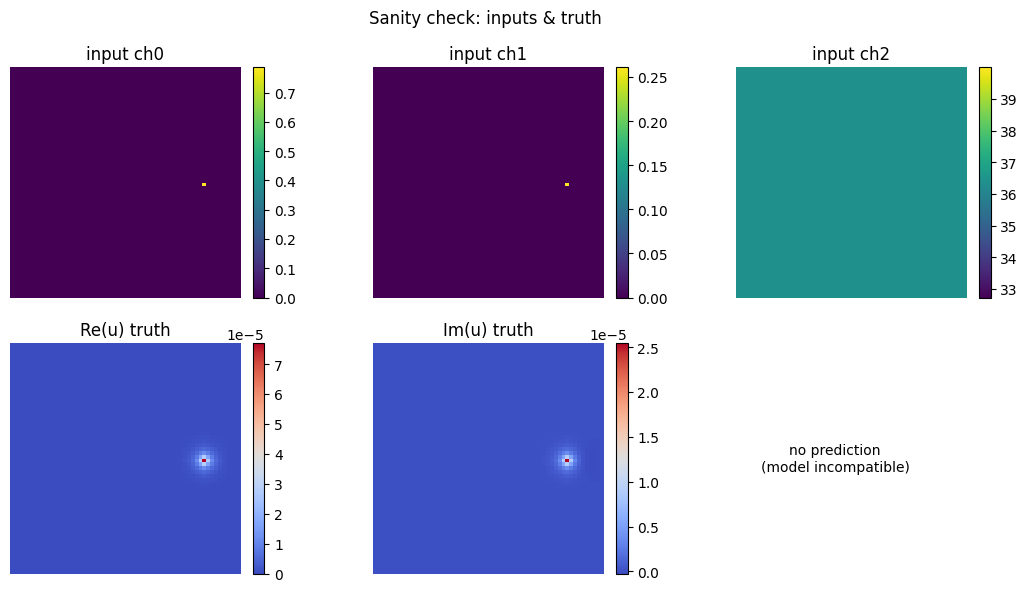

In [7]:
# Visual check of one random sample
idx = np.random.randint(0, len(data_direct["x"]))
show_example(
    model=torch.nn.Identity(),  # trick: Identity just returns x; we only want to see inputs and y truth
    data={"x": data_direct["x"], "y": data_direct["y"]},
    index=idx,
    title="Sanity check: inputs & truth"
)


5) Define a model (FNO or LocalCNN)

In [8]:
# Choose one:
model_fk = SimpleFNO(in_ch=3, out_ch=2, width=48, modes=(12, 12), layers=4).to(device)
# model_fk = LocalCNN(in_ch=3, out_ch=2, width=32, ksize=5, layers=3).to(device)

sum(p.numel() for p in model_fk.parameters()), model_fk.__class__.__name__


(5319650, 'SimpleFNO')

6) Train the model (MSE; early stopping optional)

In [9]:
# Train (uses src/training.train_model — returns hist dict {"train":[...], "val":[...]})
model_fk, hist_fk = train_model(
    model_fk, data_direct,
    epochs=40, batch_size=8, lr=1e-3, device=device,
    val_frac=0.2, seed=0,
    weight_decay=0.0,
    clip_grad_norm=None,
    use_amp=torch.cuda.is_available(),          # mixed precision on GPU
    scheduler="cosine",                         # or "step", or None
    scheduler_kw=None,
    early_stopping_patience=8,                  # stop if val stalls
    restore_best=True,
    num_workers=0, pin_memory=False,
    verbose=True
)


c:\Users\31624\Documents\MIT\Programming\basics-thesis\src\training.py:113: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=use_amp)
c:\Users\31624\Documents\MIT\Programming\basics-thesis\src\training.py:127: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp):


Epoch 001/40 | train 4.5051e-04 | val 4.4988e-06 | lr 1.00e-03
Epoch 002/40 | train 1.9878e-06 | val 3.3159e-07 | lr 9.98e-04
Epoch 003/40 | train 1.6948e-07 | val 6.5265e-08 | lr 9.94e-04
Epoch 004/40 | train 6.8024e-08 | val 5.5593e-08 | lr 9.86e-04
Epoch 005/40 | train 5.4254e-08 | val 1.0296e-07 | lr 9.76e-04
Epoch 006/40 | train 6.6817e-08 | val 9.9069e-08 | lr 9.62e-04
Epoch 007/40 | train 5.1904e-08 | val 2.3404e-08 | lr 9.46e-04
Epoch 008/40 | train 2.6363e-08 | val 3.3799e-08 | lr 9.26e-04
Epoch 009/40 | train 6.7239e-08 | val 7.2520e-08 | lr 9.05e-04
Epoch 010/40 | train 3.2146e-08 | val 2.6840e-08 | lr 8.80e-04
Epoch 011/40 | train 3.7945e-08 | val 7.1486e-08 | lr 8.54e-04
Epoch 012/40 | train 2.4916e-08 | val 1.5395e-08 | lr 8.25e-04
Epoch 013/40 | train 3.1745e-08 | val 1.4214e-07 | lr 7.94e-04
Epoch 014/40 | train 7.0424e-08 | val 9.2781e-09 | lr 7.61e-04
Epoch 015/40 | train 2.0042e-08 | val 1.5625e-08 | lr 7.27e-04
Early stopping at epoch 15. Best val 9.2781e-09.


7) Evaluate on an unseen eval set (same physics)

In [10]:
# Small eval set with same config
data_eval = build_direct_map(
    n=64,
    grid=grid,
    disc=disc,
    k_range=k_range,
    solver_fn=direct_solve,
    solver_options=direct_opts,
    pml=pml,
)

mse = evaluate_mse(model_fk, data_eval)
rel = eval_relative_metrics(model_fk, data_eval)
print(f"✅ Eval MSE: {mse:.3e}")
print(
    f"rel L2 mean={rel['rel_L2_mean']:.3f} | median={rel['rel_L2_median']:.3f} | p90={rel['rel_L2_p90']:.3f} "
    f"| mag RMSE={rel['mag_rmse']:.3e} | phase RMSE={rel['phase_rmse_rad']:.3f} rad"
)


✅ Eval MSE: 1.050e-08
rel L2 mean=34.086 | median=28.782 | p90=63.977 | mag RMSE=1.442e-04 | phase RMSE=1.805 rad


8) Visualize prediction vs ground truth (field & errors)

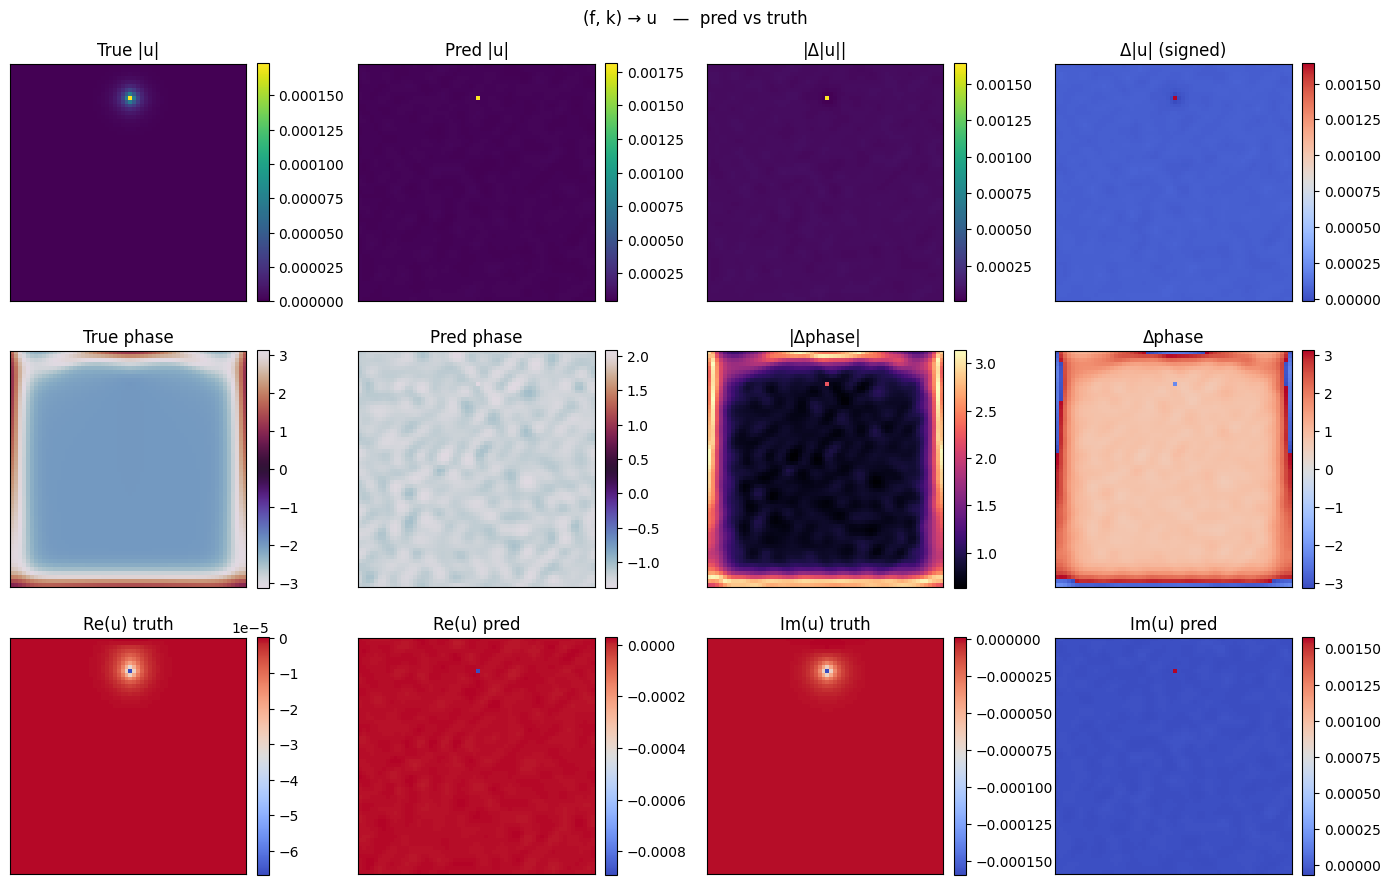

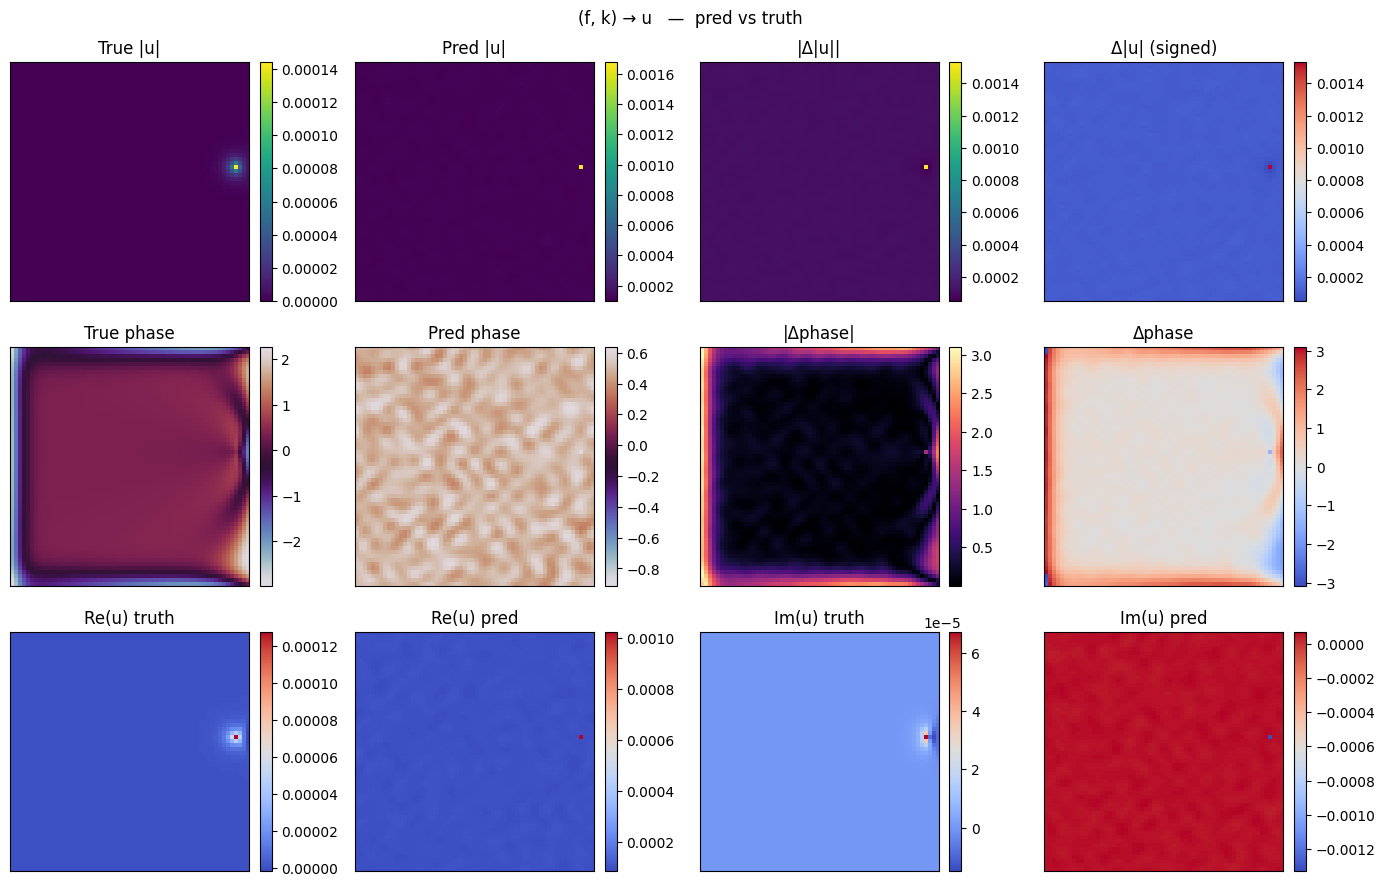

In [11]:
# Compare truth/pred for a few samples
for i in np.random.choice(len(data_eval["x"]), size=2, replace=False):
    x_i = torch.from_numpy(data_eval["x"][i:i+1]).float().to(device)
    with torch.no_grad():
        pred_i = model_fk(x_i).cpu().numpy()[0]        # (2,H,W)
    y_i = data_eval["y"][i]                             # (2,H,W)
    _ = compare_fields(y_i, pred_i, title="(f, k) → u   —  pred vs truth")


9) Save a reproducible run (weights + config + history)

In [15]:
from pathlib import Path
import time, json, torch

def new_run_dir(tag: str) -> Path:
    ts = time.strftime("%Y%m%d-%H%M%S")
    rd = runs_dir / f"{tag}_{ts}"
    rd.mkdir(parents=True, exist_ok=True)
    return rd

run_fk = new_run_dir("fk_direct")

# ---- 1) Move weights to CPU BEFORE saving (much faster & safer) ----
state_cpu = {k: v.detach().to("cpu", non_blocking=True).contiguous()
             for k, v in model_fk.state_dict().items()}

# Try safetensors first (fast, atomic), fall back to torch.save
saved_paths = []
try:
    from safetensors.torch import save_file  # pip install safetensors
    pt = run_fk / "model.safetensors"
    save_file(state_cpu, str(pt))
    saved_paths.append(pt)
except Exception:
    # legacy format; disable zip wrapper (often faster on Windows)
    pt = run_fk / "model.pt"
    torch.save(state_cpu, pt, _use_new_zipfile_serialization=False)
    saved_paths.append(pt)

# ---- 2) Save config & history ----
config_fk = {
    "task": "(f,k)->u",
    "model": model_fk.__class__.__name__,
    "in_ch": 3, "out_ch": 2, "width": 48, "modes": [12, 12], "layers": 4,
    "epochs": 40, "batch_size": 8, "lr": 1e-3,
    "grid": {"shape": list(grid.shape), "lengths": list(grid.lengths)},
    "pml": {"thickness": pml.thickness, "m": pml.m, "sigma_max": pml.sigma_max},
    "k_range": list(k_range),
    "created": time.strftime("%Y-%m-%d %H:%M:%S")
}
(run_fk / "config.json").write_text(json.dumps(config_fk, indent=2))

with open(run_fk / "train_history.csv", "w", newline="") as f:
    f.write("epoch,train_loss,val_loss\n")
    for e, (tr, vl) in enumerate(zip(hist_fk["train"], hist_fk["val"]), start=1):
        f.write(f"{e},{tr},{vl}\n")

print("✅ Saved run to:", run_fk)
for p in saved_paths:
    print("   •", p.name)


✅ Saved run to: c:\Users\31624\Documents\MIT\Programming\basics-thesis\data\runs\fk_direct_20251028-150935
   • model.pt


10) Save compact PNG snapshots for reports

Snapshot saved to: c:\Users\31624\Documents\MIT\Programming\basics-thesis\data\runs\fk_direct_20251028-150935\example_direct.png


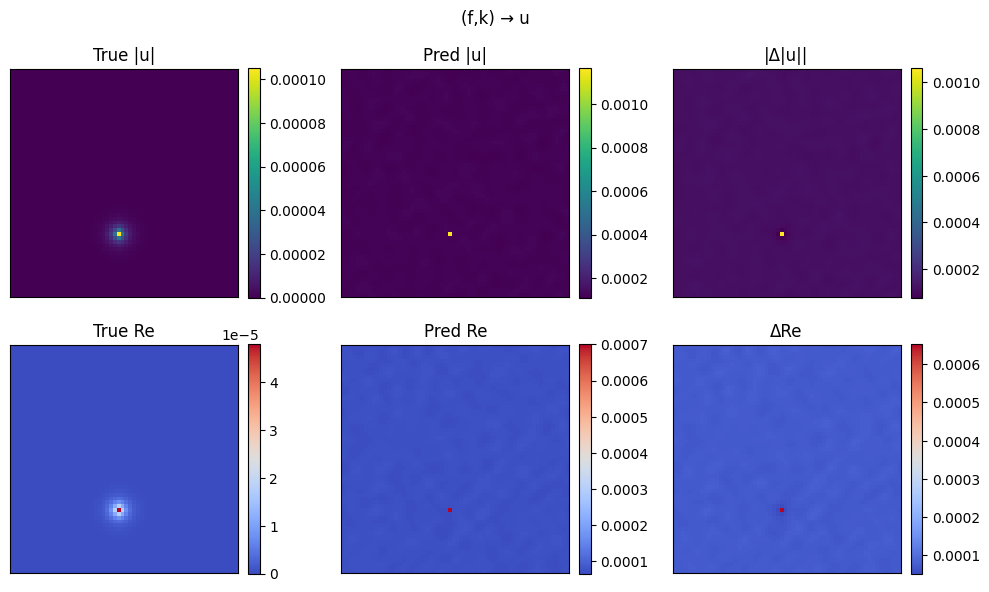

In [16]:
# Choose one sample from eval set and save a snapshot figure
i = np.random.randint(0, len(data_eval["x"]))
x_i = torch.from_numpy(data_eval["x"][i:i+1]).float().to(device)
with torch.no_grad():
    pred_i = model_fk(x_i).cpu().numpy()[0]
y_i = data_eval["y"][i]

snap_path = run_fk / "example_direct.png"
_ = save_snapshot(y_i, pred_i, out_path=snap_path, title="(f,k) → u")
print("Snapshot saved to:", snap_path)


11) Reload checkpoint & quick predict (repro check)

In [17]:
# Reload and ensure it produces the same shapes/outputs
model_fk2 = SimpleFNO(in_ch=3, out_ch=2, width=48, modes=(12, 12), layers=4).to("cpu")
state = torch.load(run_fk / "model.pt", map_location="cpu")
model_fk2.load_state_dict(state)
model_fk2.eval()

xx = torch.from_numpy(data_eval["x"][:1]).float()
with torch.no_grad():
    pp = model_fk2(xx).numpy()  # (1, 2, H, W)

print("Reloaded model, prediction shape:", pp.shape)


Reloaded model, prediction shape: (1, 2, 60, 60)
